# VGG16 — EuroSAT RGB fine-tuning

Runs the two VGG16 experiments(no-augmentation and with-augmentation) on a Colab GPU runtime. Imports `src/` modules directly

Target accuracy (paper Table 2): **98.14%** (no aug), **98.55%** (with aug).

In [1]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Andrew-Tu225/deep-transfer-learning-for-land-use-paper-implementation.git"
REPO_DIR = "/content/deep-transfer-learning-for-land-use-paper-implementation"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)

    # Mount Drive so outputs/ (checkpoints, metrics) survive a runtime disconnect —
    # a single experiment takes ~1-2h and Colab sessions can time out or recycle.
    from google.colab import drive

    drive.mount("/content/drive")
    OUTPUT_ROOT = "/content/drive/MyDrive/eurosat-lulc-outputs"
else:
    OUTPUT_ROOT = "outputs"

os.makedirs(OUTPUT_ROOT, exist_ok=True)
sys.path.insert(0, os.getcwd())
print(f"IN_COLAB={IN_COLAB} | OUTPUT_ROOT={OUTPUT_ROOT}")

Mounted at /content/drive
IN_COLAB=True | OUTPUT_ROOT=/content/drive/MyDrive/eurosat-lulc-outputs


In [2]:
import torch

assert torch.cuda.is_available(), (
    "No GPU detected — CPU training is impractical for these models "
    "(paper used a Tesla P100). In Colab: Runtime > Change runtime type > GPU."
)
print(f"Using {torch.cuda.get_device_name(0)}")

Using Tesla T4


In [3]:
import json
from dataclasses import asdict
from pathlib import Path
from types import SimpleNamespace

import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.datasets import EuroSAT

from src.data import create_dataloader
from src.models import build_vgg16
from src.training_loop import train_model

# Inlined from src/config.py (paper Sections 3.2-3.3.4) — kept local to this
# notebook cell because config.py hasn't been pushed to origin yet, and the
# Colab kernel only sees whatever has been git-cloned, not this working tree.
config = SimpleNamespace(
    NUM_CLASSES=10,
    BATCH_SIZE=64,
    VALID_SIZE=0.25,
    SEED=42,
    LEARNING_RATE=1e-4,
    MAX_EPOCHS=25,
    GRAD_CLIP_NORM=0.1,
    EARLY_STOPPING_PATIENCE=5,
    LR_SCHEDULER_FACTOR=0.1,
    LR_SCHEDULER_PATIENCE=2,
)

In [4]:
EUROSAT_CLASSES = {
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
}


def resolve_eurosat_root(download_root: str = "data") -> Path:
    """Return the ImageFolder-compatible directory holding the 10 EuroSAT class folders.

    Reuses the local copy at data/EuroSAT_RGB if present; otherwise downloads
    the RGB dataset via torchvision's built-in EuroSAT dataset (avoids
    hand-rolling a zip download) and validates the resulting layout before
    handing it to create_dataloader().
    """
    local_root = Path("data/EuroSAT_RGB")
    if local_root.is_dir() and {p.name for p in local_root.iterdir()} >= EUROSAT_CLASSES:
        return local_root

    downloaded = EuroSAT(root=download_root, download=True)
    # downloaded.root just echoes back `download_root` — torchvision nests the
    # actual class folders deeper (e.g. <root>/eurosat/2750/<ClassName>/...).
    # Derive the real ImageFolder root from where a sample file actually lives,
    # so this doesn't depend on torchvision's internal nesting convention.
    resolved = Path(downloaded.samples[0][0]).parent.parent
    found_classes = {p.name for p in resolved.iterdir() if p.is_dir()}
    if not found_classes >= EUROSAT_CLASSES:
        raise RuntimeError(
            f"Downloaded EuroSAT layout at {resolved} is missing expected class "
            f"folders: {EUROSAT_CLASSES - found_classes}"
        )
    return resolved


DATA_ROOT = resolve_eurosat_root()
print(f"DATA_ROOT={DATA_ROOT}")

100%|██████████| 94.3M/94.3M [00:01<00:00, 64.0MB/s]


DATA_ROOT=data/eurosat/2750


In [5]:
def run_experiment(run_name: str, augment: bool) -> dict:
    """Train one VGG16 experiment (Task 6) and persist metrics + best weights."""
    train_loader, val_loader, classes = create_dataloader(
        DATA_ROOT,
        augment=augment,
        valid_size=config.VALID_SIZE,
        seed=config.SEED,
        batch_size=config.BATCH_SIZE,
    )

    model = build_vgg16(num_classes=config.NUM_CLASSES)

    # Head ends in LogSoftmax (see models.py), paired with CrossEntropyLoss --
    # matches the authors' reference notebooks exactly. This is a redundant
    # log-softmax (CrossEntropyLoss applies its own), but it's the combination
    # that produced the paper's reported numbers, so we replicate it as-is.
    criterion = nn.CrossEntropyLoss()
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = Adam(trainable_params, lr=config.LEARNING_RATE)
    scheduler = ReduceLROnPlateau(
        optimizer,
        factor=config.LR_SCHEDULER_FACTOR,
        patience=config.LR_SCHEDULER_PATIENCE,
    )

    print(f"\n=== {run_name} (augment={augment}) ===")
    result = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        scheduler,
        optimizer,
        epochs=config.MAX_EPOCHS,
        max_grad_norm=config.GRAD_CLIP_NORM,
    )

    save_name = f"vgg16_{'aug' if augment else 'noaug'}"
    run_dir = Path(OUTPUT_ROOT) / save_name
    run_dir.mkdir(parents=True, exist_ok=True)
    torch.save(result.model.state_dict(), run_dir / "best.pt")

    metrics = {
        "run_name": run_name,
        "model": "vgg16",
        "augment": augment,
        "classes": classes,
        "epochs_trained": result.epochs_trained,
        "total_time_sec": result.total_time_sec,
        "best_val_accuracy": max(result.history.val_acc),
        "steps_per_epoch": len(train_loader),
        "history": asdict(result.history),
    }
    with open(run_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(
        f"Best val accuracy: {metrics['best_val_accuracy']:.4f} "
        f"(epochs_trained={metrics['epochs_trained']}, "
        f"total_time={metrics['total_time_sec'] / 60:.1f} min)"
    )
    return metrics

In [6]:
EXPERIMENTS = [
    ("vgg16_noaug", False),
    ("vgg16_aug", True),
]

results = {}
for run_name, augment in EXPERIMENTS:
    results[run_name] = run_experiment(run_name, augment)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 175MB/s]  



=== vgg16_noaug (augment=False) ===


Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

Train:   0%|          | 0/317 [00:00<?, ?it/s]

Val:   0%|          | 0/106 [00:00<?, ?it/s]

...

Train:   0%|          | 0/317 [00:00<?, ?it/s]

Val:   0%|          | 0/106 [00:00<?, ?it/s]

Train:   0%|          | 0/317 [00:00<?, ?it/s]

Val:   0%|          | 0/106 [00:00<?, ?it/s]

Best val accuracy: 0.8954 (epochs_trained=25, total_time=93.0 min)


## Next steps

- Compare `results` / `outputs/vgg16_*/metrics.json` against paper Table 2 (98.14% no-aug, 98.55% with-aug).
- Repeat this notebook's pattern for Wide ResNet-50 (`build_wide_resnet50`) once VGG16 numbers look right.
- `evaluate.py` (confusion matrix, per-class stats — Task 5) isn't implemented yet, so `02_results.ipynb` can't produce Figures 4–6 until that's built.

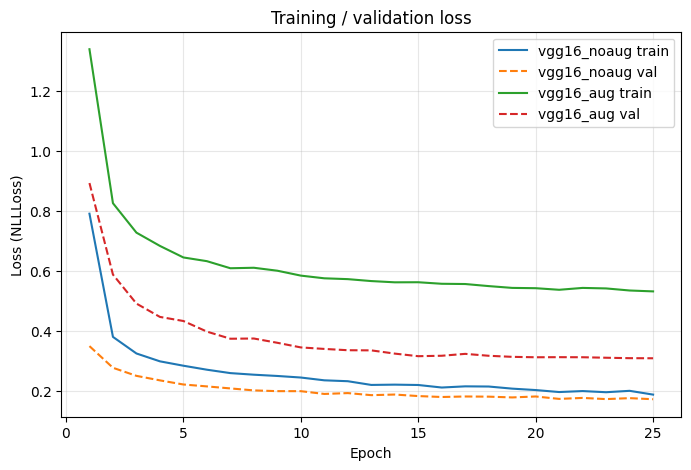

In [7]:
import matplotlib.pyplot as plt


def plot_losses(results: dict) -> None:
    """Plot per-epoch train/val loss curves for each experiment in `results` (paper Figure 4)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for run_name, metrics in results.items():
        history = metrics["history"]
        epochs = range(1, len(history["train_loss"]) + 1)
        ax.plot(epochs, history["train_loss"], label=f"{run_name} train")
        ax.plot(epochs, history["val_loss"], label=f"{run_name} val", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (NLLLoss)")
    ax.set_title("Training / validation loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

plot_losses(results)

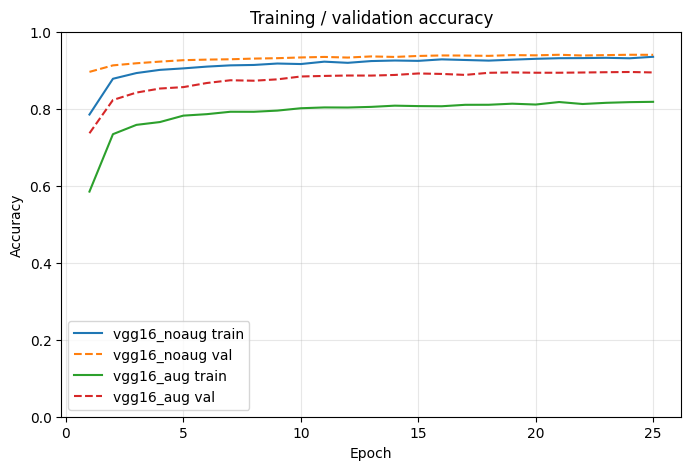

In [8]:
def plot_accuracies(results: dict) -> None:
    """Plot per-epoch train/val accuracy curves for each experiment in `results` (paper Figure 5)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for run_name, metrics in results.items():
        history = metrics["history"]
        epochs = range(1, len(history["train_acc"]) + 1)
        ax.plot(epochs, history["train_acc"], label=f"{run_name} train")
        ax.plot(epochs, history["val_acc"], label=f"{run_name} val", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Training / validation accuracy")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

plot_accuracies(results)

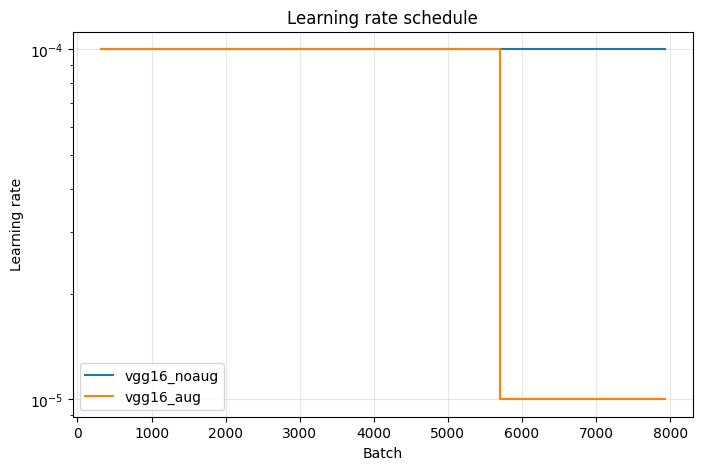

In [9]:
def plot_lr(results: dict) -> None:
    """Plot the ReduceLROnPlateau learning-rate schedule against cumulative batch count
    (matches the authors' reference notebook, which uses batch rather than epoch on the x-axis).

    LR only changes once per epoch (ReduceLROnPlateau steps on validation loss), so each
    epoch's value is held flat across all of that epoch's batches via a step plot.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    for run_name, metrics in results.items():
        history = metrics["history"]
        steps_per_epoch = metrics["steps_per_epoch"]
        batches = [epoch * steps_per_epoch for epoch in range(1, len(history["lr"]) + 1)]
        ax.step(batches, history["lr"], where="post", label=run_name)
    ax.set_xlabel("Batch")
    ax.set_ylabel("Learning rate")
    ax.set_yscale("log")
    ax.set_title("Learning rate schedule")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

plot_lr(results)